### PERCEPCION COVID PERSISTENTE con "Redes Neuronales" (2)

In [1]:
pip install pandas numpy scikit-learn tensorflow matplotlib seaborn openpyxl

Note: you may need to restart the kernel to use updated packages.


2025-08-21 18:39:03.070783: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-08-21 18:39:13.644422: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-08-21 18:39:33.855754: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


Dimensiones del dataset: (360, 34)
Pacientes con COVID prolongado: 360


/home/abellugu/anaconda3/lib/python3.12/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2025-08-21 18:39:46.052066: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


Resumen del modelo:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         2,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,865 (19.00 KB)

 Trainable params: 4,865 (19.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 99ms/step - accuracy: 0.9522 - loss: 0.3160 - precision: 1.0000 - recall: 0.9522 - val_accuracy: 1.0000 - val_loss: 0.2302 - val_precision: 1.0000 - val_recall: 1.0000
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 1.0000 - loss: 0.1720 - precision: 1.0000 - recall: 1.0000 - val_accuracy: 1.0000 - val_loss: 0.1245 - val_precision: 1.0000 - val_recall: 1.0000
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 1.0000 - loss: 0.0931 - precision: 1.0000 - recall: 1.0000 - val_accuracy: 1.0000 - val_loss: 0.0630 - val_precision: 1.0000 - val_recall: 1.0000
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 1.0000 - loss: 0.0540 - precision: 1.0000 - recall: 1.0000 - val_accuracy: 1.0000 - val_loss: 0.0314 - val_precision: 1.0000 - val_recall: 1.0000
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 1.0000 - loss: 0.0352 - precision: 1.0000 - recall: 1.0000 - val_accuracy: 1.0000 - val_loss: 0.0168 - val

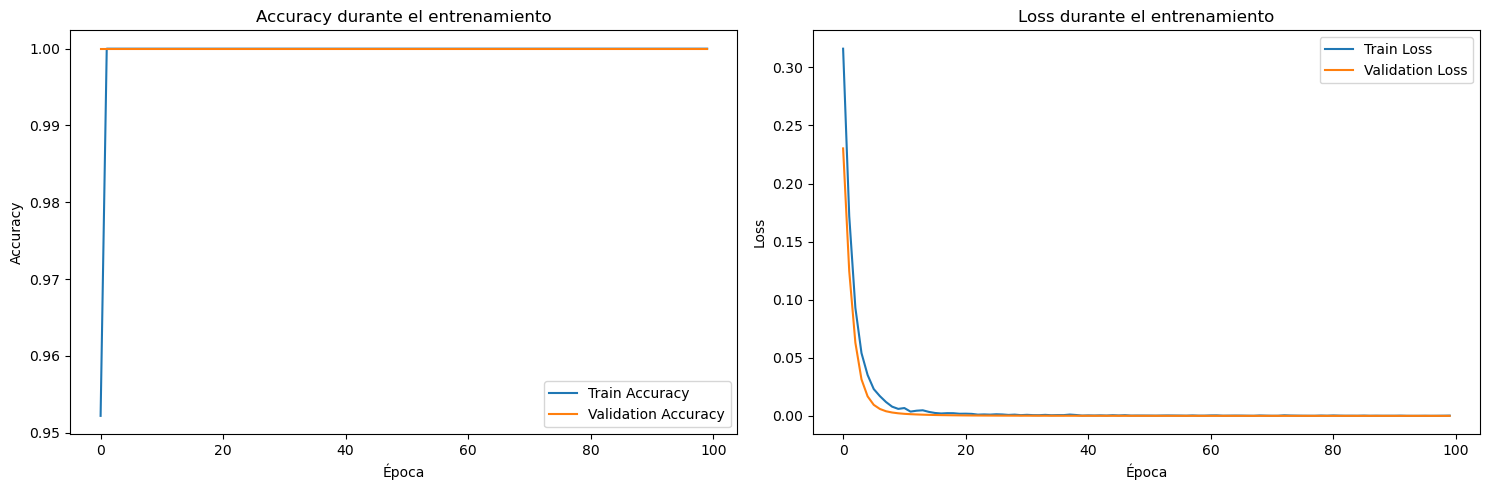

/home/abellugu/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:409: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


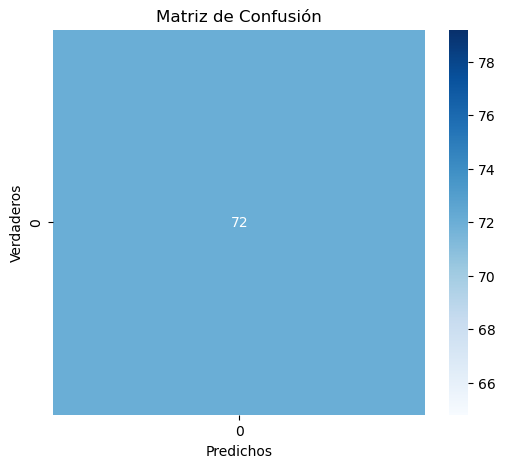


Top 10 características más importantes:
                                              feature  importance
29  ¿Qué tipo de síntomas persistentes tiene o ha ...    0.156446
3   Fatiga 4. La fatiga interfiere con mi funciona...    0.151549
11          Estado de ánimo 3. Me siento feliz (1-10)    0.144070
16        Estado de ánimo 8. Me siento enojado (1-10)    0.143836
22       Estado de ánimo 14. Me siento enojado (1-10)    0.142792
30  ¿Qué tipo de síntomas persistentes tiene o ha ...    0.141566
20        Estado de ánimo 12. Me siento alegre (1-10)    0.141154
19       Estado de ánimo 11. Me siento molesto (1-10)    0.140703
28  ¿Qué tipo de síntomas persistentes tiene o ha ...    0.140633
33  ¿Qué tipo de síntomas persistentes tiene o ha ...    0.136553

Modelo guardado como 'covid_largo_model.h5'


In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar los datos
df = pd.read_excel('percepcion_covid_persistente.xlsx', sheet_name='Respuestas de formulario 1')

# 1. Preprocesamiento
# Filtrar solo pacientes con COVID prolongado (B = 1)
df = df[df['¿Es usted un paciente con síntomas prolongados de COVID-19?'] == 1]

# Definir variables
# Fatiga (columns C-K, 9 items)
fatiga_columns = df.columns[2:11]  # C a K

# Estado de ánimo (columns L-AA, 16 items)
estado_animo_columns = df.columns[11:27]  # L a AA

# Síntomas persistentes (columns AB-AJ, 9 items)
sintomas_columns = df.columns[27:36]  # AB a AJ

# Combinar todas las features
feature_columns = list(fatiga_columns) + list(estado_animo_columns) + list(sintomas_columns)

# Crear dataset final
X = df[feature_columns].values
y = df['¿Es usted un paciente con síntomas prolongados de COVID-19?'].values  # Todos serán 1

print(f"Dimensiones del dataset: {X.shape}")
print(f"Pacientes con COVID prolongado: {len(y)}")

# 2. Dividir en train/test (aunque todos son positivos, podemos usar para validación)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Normalizar los datos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Construir el modelo de red neuronal
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', 'precision', 'recall']
)

print("Resumen del modelo:")
model.summary()

# 5. Entrenar el modelo
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train_scaled, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=1
)

# 6. Evaluar el modelo
y_pred_proba = model.predict(X_test_scaled)
y_pred = (y_pred_proba > 0.5).astype(int)

print("\n" + "="*50)
print("EVALUACIÓN DEL MODELO")
print("="*50)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# 7. Visualizaciones
plt.figure(figsize=(15, 5))

# Gráfico de accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy durante el entrenamiento')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()

# Gráfico de loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss durante el entrenamiento')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# 8. Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusión')
plt.ylabel('Verdaderos')
plt.xlabel('Predichos')
plt.show()

# 9. Análisis de importancia de características (usando pesos de la red)
def get_feature_importance(model, feature_names):
    """Obtener importancia de características basada en pesos de la primera capa"""
    weights = model.layers[0].get_weights()[0]
    importance = np.mean(np.abs(weights), axis=1)
    feature_importance = pd.DataFrame({
        'feature': feature_names,
        'importance': importance
    }).sort_values('importance', ascending=False)
    
    return feature_importance

feature_importance = get_feature_importance(model, feature_columns)

print("\nTop 10 características más importantes:")
print(feature_importance.head(10))

# 10. Guardar el modelo
model.save('covid_largo_model.h5')
print("\nModelo guardado como 'covid_largo_model.h5'")

# 11. Función para hacer predicciones
def predict_covid_largo(nuevos_datos):
    """
    Función para predecir si un paciente tiene COVID prolongado
    
    nuevos_datos: array o dataframe con las 34 características en el mismo orden
    """
    nuevos_datos_scaled = scaler.transform(nuevos_datos)
    prediccion = model.predict(nuevos_datos_scaled)
    probabilidad = prediccion[0][0]
    
    print(f"Probabilidad de COVID prolongado: {probabilidad:.4f}")
    print(f"Predicción: {'SÍ' if probabilidad > 0.5 else 'NO'} tiene COVID prolongado")
    
    return probabilidad

# Ejemplo de uso:
# predict_covid_largo(X_test_scaled[0:1])